In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [22]:
#load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 7043
Columns: 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#top5rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
#bottom5rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
#missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
#cleaning and fixing the TargetCharges column, invalid values converted to Nan
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(0) # new customers
df['TotalCharges'].isnull().sum()

np.int64(0)

In [24]:
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# overall churn rate
overall_churn = df['Churn_Binary'].mean() * 100
print(f"\nOverall churn rate: {overall_churn:.2f}%")
print(f"Churned: {df['Churn_Binary'].sum():,} out of {len(df):,} customers")


Overall churn rate: 26.54%
Churned: 1,869 out of 7,043 customers


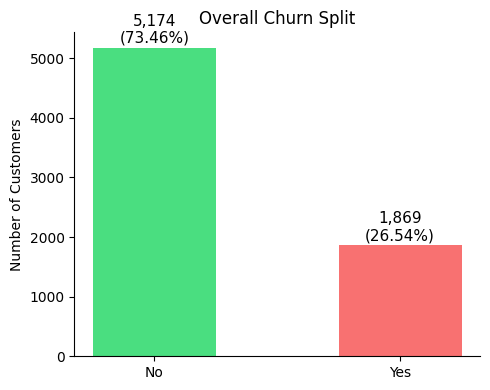

In [25]:
#overall churn distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Churn'].value_counts()
colors = ['#4ade80', '#f87171']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}\n({val/len(df)*100:.2f}%)",
            ha='center', va='bottom', fontsize=11)
ax.set_title("Overall Churn Split")
ax.set_ylabel("Number of Customers")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#26.54% customers churned - this is baseline

In [11]:
def churn_rate_by(col):
    return (
        df.groupby(col)['Churn_Binary']
        .mean()
        .mul(100)          # convert to percentage
        .round(1)
        .reset_index()
        .rename(columns={'Churn_Binary': 'Churn_Rate_%'})
        .sort_values('Churn_Rate_%', ascending=False)
    )

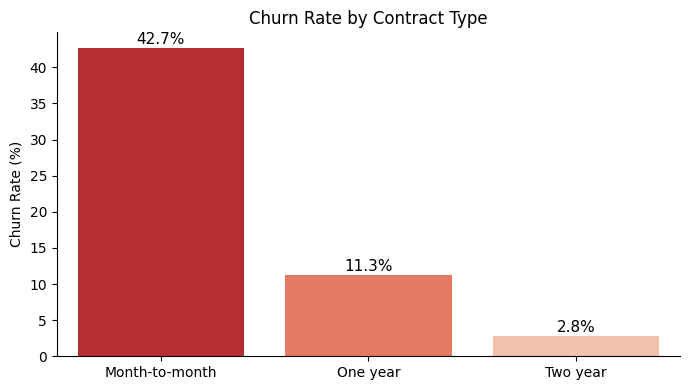

In [12]:
#contract_churn
contract_churn = churn_rate_by('Contract')

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=contract_churn, x='Contract', y='Churn_Rate_%',
            palette='Reds_r', ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Month-to-month contract customers churn at 42.7%,
#much higher than yearly or two-year contract customers.
#It can be concluded that contract type is the strongest predictor

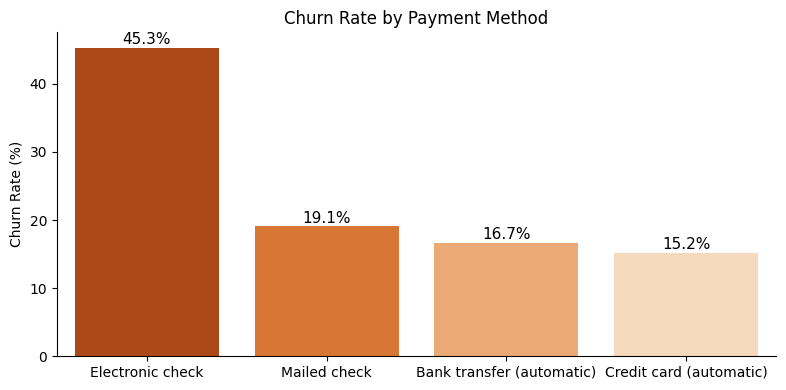

In [26]:
#payment_churn
payment_churn = churn_rate_by('PaymentMethod')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Rate_%',
            palette='Oranges_r', ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Electronic check users churn most,
#which indicates possibly less committed customers

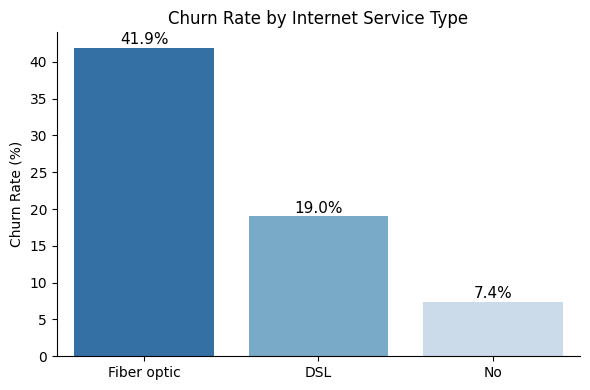

In [27]:
#internet churn
internet_churn = churn_rate_by('InternetService')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=internet_churn, x='InternetService', y='Churn_Rate_%',
            palette='Blues_r', ax=ax)
ax.set_title("Churn Rate by Internet Service Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Fiber optic customers churn mouchmore than DSL customers,
#which indicates possible pricing or service quality issue.

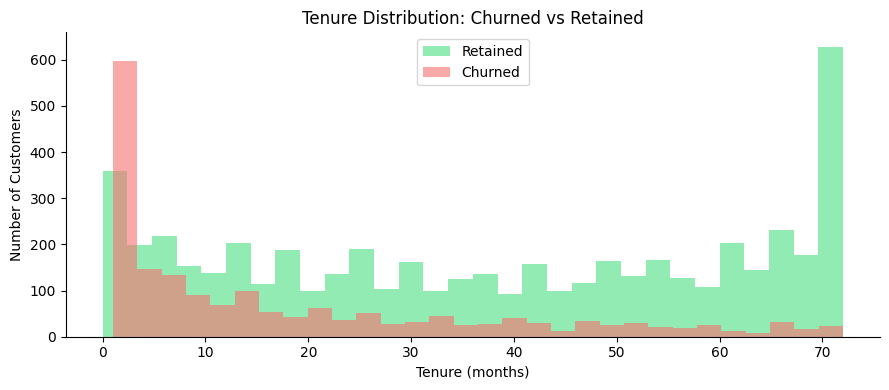

In [15]:
#distribution, churned vs retained
fig, ax = plt.subplots(figsize=(9, 4))

df[df['Churn'] == 'No']['tenure'].plot(kind='hist', bins=30, alpha=0.6,
                                        color='#4ade80', label='Retained', ax=ax)
df[df['Churn'] == 'Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.6,
                                         color='#f87171', label='Churned', ax=ax)

ax.set_title("Tenure Distribution: Churned vs Retained")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Most churned customers have very short tenure (0-12 months),
#long-term customers are uch less likely to leave

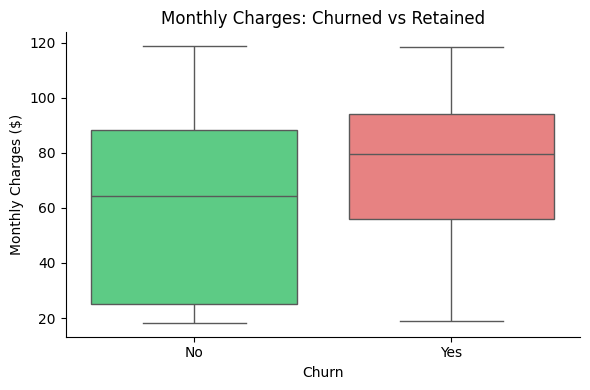

In [28]:
#monthly charges plot
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#4ade80', 'Yes': '#f87171'}, ax=ax)
ax.set_title("Monthly Charges: Churned vs Retained")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Churned customers pay significantly higher monthly charges on average.
#Higher price may drive dissatisfaction among customers

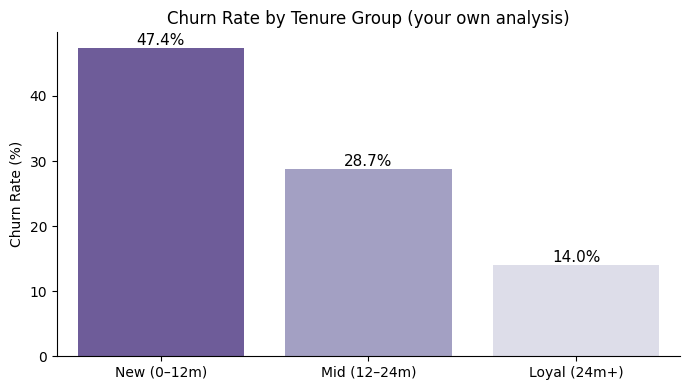

In [29]:
#different tenure groups(new, mid, loyal)
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 72],
                             labels=['New (0–12m)', 'Mid (12–24m)', 'Loyal (24m+)'],
                             include_lowest=True)

tenure_churn = churn_rate_by('Tenure_Group')

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=tenure_churn, x='Tenure_Group', y='Churn_Rate_%',
            palette='Purples_r', ax=ax)
ax.set_title("Churn Rate by Tenure Group (your own analysis)")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#New customers(0-12m) churn at 47.4%
#which is nearly 3 times higher than loyal customers (24m+),
#thus early retention is critical

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

#load data
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#data cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

#Feature Engineering
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1','1-2','2-4','4-6'])
df['avg_charges'] = df['TotalCharges'] / (df['tenure'] + 1)

#Split
X = df.drop('Churn', axis=1)
y = df['Churn']

# Correctly identify numerical and categorical columns, include 'category' dtype in cat_cols
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(exclude=['object', 'category']).columns

#preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Logistic Regression model
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

#Handle imbalance
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

#XGB model
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.7525807951639154
XGBoost
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.73      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC: 0.7470988658968198


In [19]:
#Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs']
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=3, scoring='recall')
lr_grid.fit(X_train, y_train)

# XGBoost Pipeline
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos
    ))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=3, scoring='recall')
xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'avg_charges'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecur...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='recall')

In [20]:
# Compare recall scores
print("LR Best Recall:", lr_grid.best_score_)
print("XGB Best Recall:", xgb_grid.best_score_)

# Select best model
best_model = lr_grid if lr_grid.best_score_ > xgb_grid.best_score_ else xgb_grid

# Predictions
y_pred = best_model.best_estimator_.predict(X_test)

print("Best Model:", type(best_model.best_estimator_.named_steps['model']).__name__)
print("Best Params:", best_model.best_params_)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

LR Best Recall: 0.79600298320872
XGB Best Recall: 0.8033536953424921
Best Model: XGBClassifier
Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.7660621560877315


In [ ]:
#For the churn problem, I proritize recall for the churn class. Based on cross validation, XGB achieved
#higher recall, so I selected it as the final model. Cross validation gives a more reliable estimate than
#a single test split


Confusion Matrix:
 [[750 285]
 [ 72 302]]


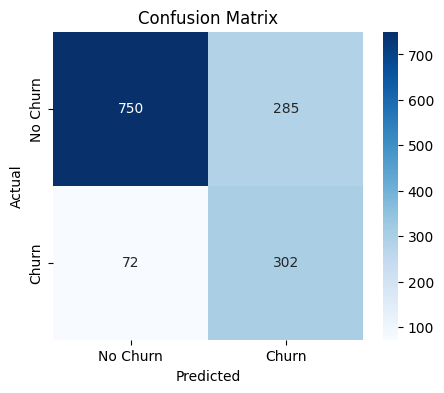

In [21]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from best model
y_pred = best_model.best_estimator_.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#750(top left) -> True negatives -> Correctly predicted No Churn
#285(top right) -> False positives -> Predicted churn, but actually No churn
#72(Bottom left) -> False negatives -> Missed churn customers(VERY IMPORTANT)
#302(Bottom right) -> True Positives -> Correctly predicted churn

#Model correctly identified 302 churn customers
#Only 72 churn customers missed -> GOOD (low FN)
#Some over-prediction of churn(285 FP) -> acceptable trade-off


#BUSINESS INTERPRETATION
#we're catching most churn customer -> GOOD
#missing fewer churn customers -> less revenue loss
#slightly higher false alarms(FP) -> manageable(just extra offers)

In [30]:
#Tradeoffs
#Logistic Regression is simple and interpretable, while
#XGB provides better predictive power but at the cost of complexity and interpretability

In [31]:
#Conclusion
#For this Telco churn problem, I selected XGB as the final model because it achieved higher
#recall durig cross validation, which is critical for identifying churn customers. While LogisticRegression
#is more interpretable, XGB provides etter predictive performance and handles complex patterns and class imbalance
#more effectively. Therefore, it aligns better with the business objective of minimizing customer churn

In [32]:
#further improvements
#I would focus on improving recall through better feature engineering,
#threshold tuning and advanced hyperparameter optimization while ensuring
#model intepretability using SHAP